In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset_OData_Final_Martin_Otero.csv")

In [33]:
pd.options.display.max_columns = None
print(df.columns.to_list())

['FlightDate', 'sched_dep_dt', 'sched_arr_dt', 'dep_dt', 'arr_dt', 'Airline', 'Origin', 'Dest', 'DepDelayMinutes', 'DepDelay', 'ArrDelayMinutes', 'TotalDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime', 'Distance', 'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'Operating_Airline', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline', 'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'ArrDelay', 'ArrDel15', 'ArrivalDelayGroups', 'ArrTimeBlk', 'DistanceGroup', 'DivAirportLandings', 'o

In [34]:
df.head(5)


,FlightDate,sched_dep_dt,sched_arr_dt,dep_dt,arr_dt,Airline,Origin,Dest,DepDelayMinutes,DepDelay,ArrDelayMinutes,TotalDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings,origin_lat,origin_lon,dest_lat,dest_lon,aircraft_age,MODEL,TotalDelayMinutes.1
0,2021-03-03,2021-03-03 07:24:00,2021-03-03 08:43:00,2021-03-03 07:14:00,2021-03-03 08:18:00,SkyWest Airlines Inc.,SGU,PHX,0.0,-10.0,0.0,0.0,49.0,79.0,64.0,262.0,AA,AA_CODESHARE,19805,AA,3133,SkyWest Airlines Inc.,20304,OO,N728SK,3133,14794,1479405,34794,"St. George, UT",UT,49,Utah,87,14107,1410702,30466,"Phoenix, AZ",AZ,4,Arizona,81,0.0,-1.0,0700-0759,10.0,724.0,813.0,5.0,-25.0,0.0,-2.0,0800-0859,2,0.0,37.036389,-113.510306,33.435302,-112.005905,16.0,CL-600-2C10,0.0
1,2021-03-03,2021-03-03 09:22:00,2021-03-03 10:40:00,2021-03-03 09:17:00,2021-03-03 10:31:00,SkyWest Airlines Inc.,PHX,SGU,0.0,-5.0,0.0,0.0,48.0,78.0,74.0,262.0,AA,AA_CODESHARE,19805,AA,3134,SkyWest Airlines Inc.,20304,OO,N752SK,3134,14107,1410702,30466,"Phoenix, AZ",AZ,4,Arizona,81,14794,1479405,34794,"St. George, UT",UT,49,Utah,87,0.0,-1.0,0900-0959,23.0,940.0,1028.0,3.0,-9.0,0.0,-1.0,1000-1059,2,0.0,33.435302,-112.005905,37.036389,-113.510306,16.0,CL-600-2C10,0.0
2,2021-03-03,2021-03-03 13:30:00,2021-03-03 15:30:00,2021-03-03 13:21:00,2021-03-03 15:01:00,SkyWest Airlines Inc.,MHT,ORD,0.0,-9.0,0.0,0.0,129.0,180.0,160.0,843.0,AA,AA_CODESHARE,19805,AA,3135,SkyWest Airlines Inc.,20304,OO,N766SK,3135,13296,1329604,30721,"Manchester, NH",NH,33,New Hampshire,14,13930,1393007,30977,"Chicago, IL",IL,17,Illinois,41,0.0,-1.0,1300-1359,15.0,1336.0,1445.0,16.0,-29.0,0.0,-2.0,1500-1559,4,0.0,42.932598,-71.435699,41.978600,-87.904800,16.0,CL-600-2C10,0.0
3,2021-03-03,2021-03-03 16:45:00,2021-03-03 20:10:00,2021-03-03 16:36:00,2021-03-03 20:02:00,SkyWest Airlines Inc.,DFW,TRI,0.0,-9.0,0.0,0.0,112.0,145.0,146.0,868.0,AA,AA_CODESHARE,19805,AA,3136,SkyWest Airlines Inc.,20304,OO,N752EV,3136,11298,1129806,30194,"Dallas/Fort Worth, TX",TX,48,Texas,74,15323,1532305,35323,"Bristol/Johnson City/Kingsport, TN",TN,47,Tennessee,54,0.0,-1.0,1600-1659,27.0,1703.0,1955.0,7.0,-8.0,0.0,-1.0,2000-2059,4,0.0,32.896801,-97.038002,36.475201,-82.407401,NaN,CL-600-2C10,0.0
4,2021-03-03,2021-03-03 18:44:00,2021-03-03 19:25:00,2021-03-03 18:38:00,2021-03-03 19:03:00,SkyWest Airlines Inc.,PHX,BFL,0.0,-6.0,0.0,0.0,69.0,101.0,85.0,425.0,AA,AA_CODESHARE,19805,AA,3137,SkyWest Airlines Inc.,20304,OO,N715SK,3137,14107,1410702,30466,"Phoenix, AZ",AZ,4,Arizona,81,10561,1056103,30561,"Bakersfield, CA",CA,6,California,91,0.0,-1.0,1800-1859,13.0,1851.0,1900.0,3.0,-22.0,0.0,-2.0,1900-1959,2,0.0,33.435302,-112.005905,35.433601,-119.056999,17.0,CL-600-2C10,0.0


In [35]:
print(df.shape)
for i in df.columns:
    print(i, df[i].nunique())

(6107533, 62)
FlightDate 365
sched_dep_dt 393425
sched_arr_dt 429035
dep_dt 433241
arr_dt 451598
Airline 22
Origin 372
Dest 372
DepDelayMinutes 1597
DepDelay 1659
ArrDelayMinutes 1597
TotalDelayMinutes 2886
AirTime 670
CRSElapsedTime 589
ActualElapsedTime 697
Distance 1573
Marketing_Airline_Network 10
Operated_or_Branded_Code_Share_Partners 15
DOT_ID_Marketing_Airline 10
IATA_Code_Marketing_Airline 10
Flight_Number_Marketing_Airline 7000
Operating_Airline 22
DOT_ID_Operating_Airline 22
IATA_Code_Operating_Airline 21
Tail_Number 5752
Flight_Number_Operating_Airline 7000
OriginAirportID 372
OriginAirportSeqID 372
OriginCityMarketID 348
OriginCityName 366
OriginState 50
OriginStateFips 50
OriginStateName 50
OriginWac 50
DestAirportID 372
DestAirportSeqID 372
DestCityMarketID 348
DestCityName 366
DestState 50
DestStateFips 50
DestStateName 50
DestWac 50
DepDel15 2
DepartureDelayGroups 15
DepTimeBlk 19
TaxiOut 182
WheelsOff 1440
WheelsOn 1440
TaxiIn 208
ArrDelay 1687
ArrDel15 2
ArrivalDelay

# **Clasificacion Binaria:** Arrival delay >15

- Regresion Logistica
- Arbol
- Random Forest
- XGBoost

In [36]:
from sklearn.model_selection import train_test_split
import pandas as pd
from category_encoders import LeaveOneOutEncoder

# --- 1. CONFIGURACIÓN DEL SPLIT ---
target_bin = 'ArrDel15'

# Solo mantengo en cols_to_drop lo que es leakage puro de llegada o redundante
cols_to_drop_initial = [
    target_bin, 'TotalDelayMinutes', 'TotalDelayMinutes.1', 'ArrDelay', 
    'ArrDelayMinutes', 'TaxiIn', 'WheelsOn', 'ActualElapsedTime', 
    'ArrivalDelayGroups', 'DepartureDelayGroups', 'DivAirportLandings',
    'DepDel15', "AirTime"]

X_bin = df.drop(columns=[c for c in cols_to_drop_initial if c in df.columns])
y_bin = df[target_bin]

# Mantengo el split al 5% para test por el volumen de datos (6M)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.05, random_state=42, stratify=y_bin
)

print(f"Split para llegada completado. Target: {target_bin}")


Split para llegada completado. Target: ArrDel15


In [ ]:
# --- 2. EXTRACCIÓN DE VARIABLES TEMPORALES ---
def extract_time_features(df):
    df = df.copy()
    df['sched_dep_dt'] = pd.to_datetime(df['sched_dep_dt'])
    df['sched_month'] = df['sched_dep_dt'].dt.month
    df['sched_dayofweek'] = df['sched_dep_dt'].dt.dayofweek
    df['hour'] = df['sched_dep_dt'].dt.hour
    df['is_late_night'] = (df['hour'] >= 18).astype(int)
    return df

X_train_bin = extract_time_features(X_train_bin)
X_test_bin = extract_time_features(X_test_bin)

# --- 3. SELECCIÓN Y LIMPIEZA FINAL ---
target_encode_cols = [
    'Airline', 'Origin', 'Dest', 'MODEL', 
    'Marketing_Airline_Network', 'Operating_Airline',
    'OriginStateName', 'DestStateName'
]

# He añadido las coordenadas y textos residuales a la limpieza final
cols_to_drop_final = [
    'FlightDate', 'sched_dep_dt', 'sched_arr_dt', 'dep_dt', 'arr_dt', 
    'Tail_Number', 'Flight_Number_Marketing_Airline', 'Flight_Number_Operating_Airline', 
    'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginState', 'OriginStateFips', 'OriginWac',
    'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestState', 'DestStateFips', 'DestWac',
    'OriginCityName', 'DestCityName', 'DepTimeBlk', 'ArrTimeBlk',
    'origin_lat', 'origin_lon', 'dest_lat', 'dest_lon',
    'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 
    'IATA_Code_Marketing_Airline', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline'
]

X_train_bin = X_train_bin.drop(columns=[c for c in cols_to_drop_final if c in X_train_bin.columns])
X_test_bin = X_test_bin.drop(columns=[c for c in cols_to_drop_final if c in X_test_bin.columns])

# --- 4. LEAVE-ONE-OUT ENCODING ---
# Ajusto el encoder sobre el target de llegada
loo_encoder = LeaveOneOutEncoder(cols=target_encode_cols)

print("Iniciando codificación para el modelo de llegada...")
X_train_encoded = loo_encoder.fit_transform(X_train_bin, y_train_bin)
X_test_encoded = loo_encoder.transform(X_test_bin)

print("Codificación finalizada.")
print(f"Variables listas para el modelo: {X_train_encoded.columns.tolist()}")

Iniciando codificación para el modelo de llegada...


In [ ]:
X_train_encoded.head()

,Airline,Origin,Dest,DepDelayMinutes,CRSElapsedTime,Distance,Marketing_Airline_Network,Operating_Airline,OriginStateName,DestStateName,TaxiOut,WheelsOff,DistanceGroup,aircraft_age,MODEL,sched_month,sched_dayofweek,hour,is_late_night
5044668,0.174244,0.205232,0.178607,124.0,148.0,925.0,0.165422,0.174244,0.210259,0.116220,15.0,2119.0,4,8.0,0.203236,10,4,19,1
4516872,0.139547,0.134158,0.185674,0.0,112.0,427.0,0.111048,0.139547,0.145172,0.173206,13.0,713.0,2,13.0,0.145945,5,6,7,0
1546934,0.115523,0.231170,0.112877,1.0,112.0,577.0,0.111048,0.115523,0.229424,0.116223,9.0,1010.0,3,3.0,0.116890,11,0,10,0
5987740,0.158082,0.115223,0.116157,0.0,78.0,284.0,0.111048,0.158082,0.162598,0.116494,9.0,1327.0,2,0.0,0.126577,6,3,13,0
2001324,0.173366,0.160256,0.155629,0.0,69.0,262.0,0.181702,0.173366,0.157293,0.171426,13.0,1413.0,2,20.0,0.175572,11,3,14,0


## Regresion Logistica

Iniciando búsqueda de hiperparámetros...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END ....................................logreg__C=0.001; total time=  26.1s
[CV] END ....................................logreg__C=0.001; total time=  22.9s
[CV] END ....................................logreg__C=0.001; total time=  24.1s
[CV] END .....................................logreg__C=0.01; total time=  23.8s
[CV] END .....................................logreg__C=0.01; total time=  22.8s
[CV] END .....................................logreg__C=0.01; total time=  23.3s
[CV] END ......................................logreg__C=0.1; total time=  24.5s
[CV] END ......................................logreg__C=0.1; total time=  21.8s
[CV] END ......................................logreg__C=0.1; total time=  21.6s
[CV] END ........................................logreg__C=1; total time=  21.9s
[CV] END ........................................logreg__C=1; total time=  21.9s
[CV] END

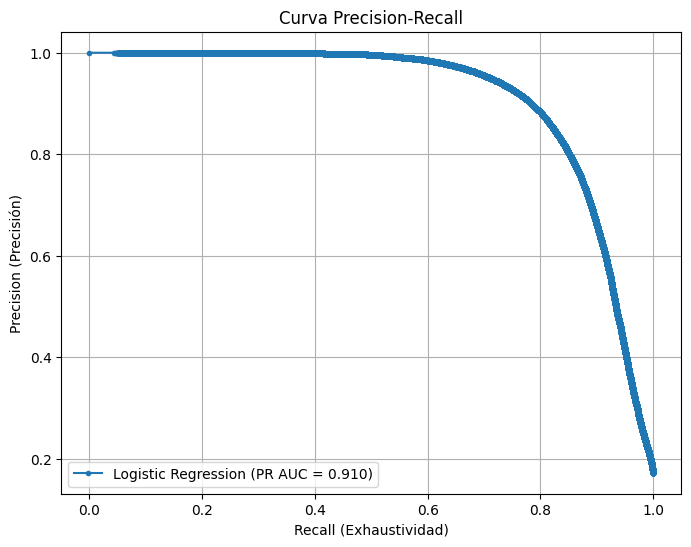

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Defino mi Pipeline (Imputacion -> Escalado -> Modelo)
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Cubre el NaN de aircraft_age
    ('scaler', StandardScaler()),                  # Vital para la regresión logística
    ('logreg', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# 2. Espacio de búsqueda de hiperparámetros (Regularización C)
# Valores pequeños = mucha regularización (modelo más simple), Valores grandes = menos regularización
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10]
}

# 3. Configuro GridSearchCV priorizando el PR AUC (average_precision)
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=3,                      # 3-fold cross validation para no tardar una eternidad con 6M de filas
    scoring='average_precision', # Optimizamos específicamente para la curva PR
    verbose=2, 
    n_jobs=1                  
)

# 4. Entreno el modelo (¡Esto llevará un rato con tus datos!)
print("Iniciando búsqueda de hiperparámetros...")
grid_search.fit(X_train_encoded, y_train_bin)

# 5. Extraigo mi mejor modelo
best_model = grid_search.best_estimator_
print(f"Mejor parámetro C encontrado: {grid_search.best_params_['logreg__C']}")

# 6. Predicciones y Probabilidades sobre el set de prueba
y_pred = best_model.predict(X_test_encoded)
y_probs = best_model.predict_proba(X_test_encoded)[:, 1] # Probabilidad de la clase 1 (Retraso)

# 7. Reporte de Métricas Clásicas
print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test_bin, y_pred))

# 8. Gráfica de la Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test_bin, y_probs)
pr_auc = average_precision_score(y_test_bin, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'Logistic Regression (PR AUC = {pr_auc:.3f})')
plt.xlabel('Recall (Exhaustividad)')
plt.ylabel('Precision (Precisión)')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_8740\1879755688.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coeficiente', y='Variable', palette='viridis')


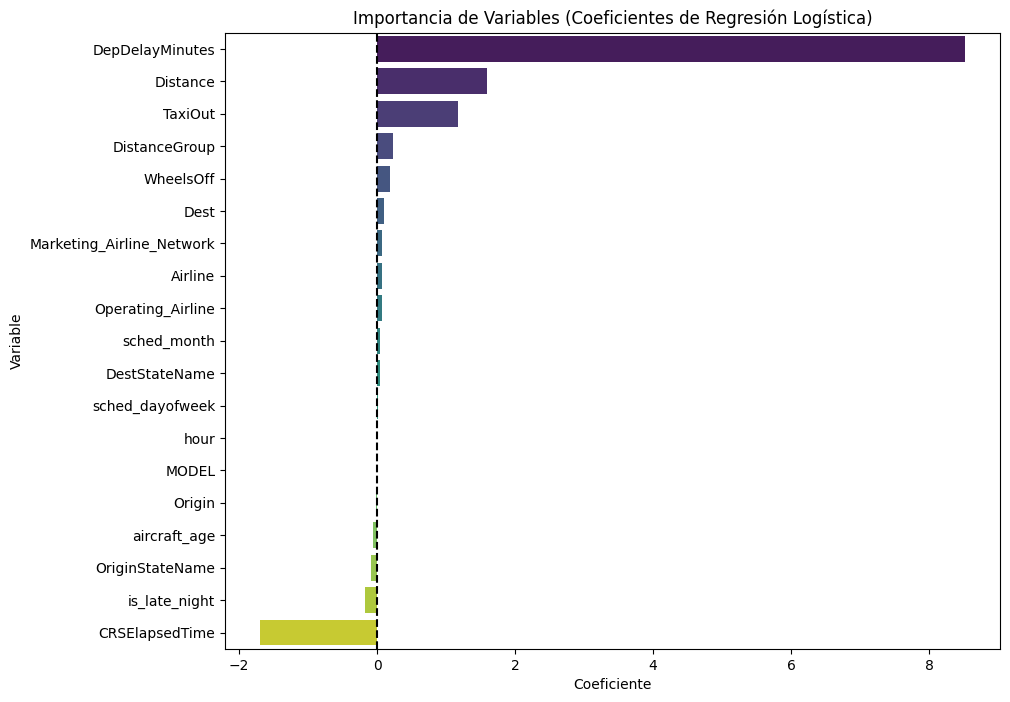

La variable con mayor impacto positivo es: DepDelayMinutes


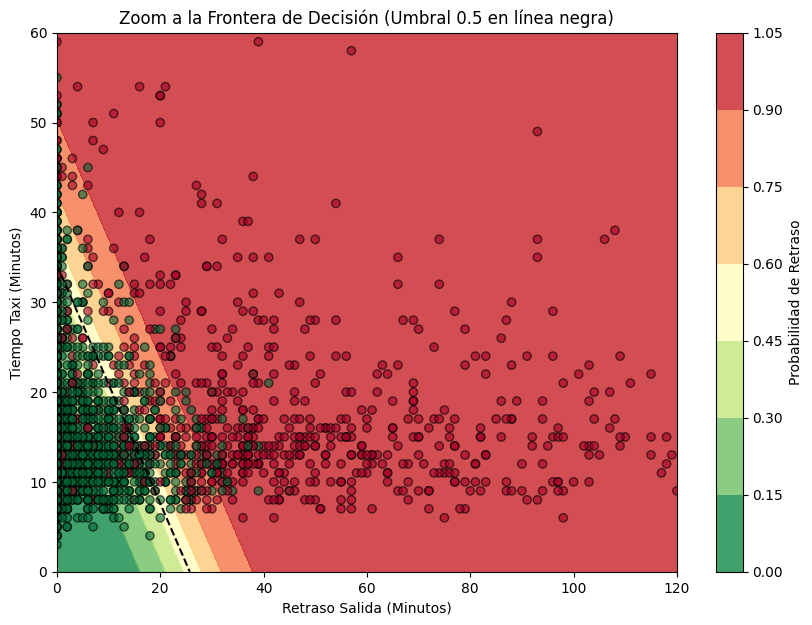

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraemos los coeficientes del modelo entrenado
# Accedemos a través de 'best_model' que es tu GridSearchCV.best_estimator_
model_inner = best_model.named_steps['logreg']
feature_names = X_train_encoded.columns
coefficients = model_inner.coef_[0]

# 2. Creamos un DataFrame para visualizar
importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coefficients
}).sort_values(by='Coeficiente', ascending=False)

# 3. Graficamos
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Coeficiente', y='Variable', palette='viridis')
plt.title('Importancia de Variables (Coeficientes de Regresión Logística)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

print("La variable con mayor impacto positivo es:", importance_df.iloc[0]['Variable'])


sample = X_test_encoded.sample(5000, random_state=42)
var1 = 'DepDelayMinutes'
var2 = 'TaxiOut'
medians = X_test_encoded.median()
plt.figure(figsize=(10, 7))

# Limitamos a valores razonables (0 a 120 min de retraso y 0 a 60 de taxi)
x_zoom = np.linspace(0, 120, 100)
y_zoom = np.linspace(0, 60, 100)
xx_z, yy_z = np.meshgrid(x_zoom, y_zoom)

# Preparamos datos para la predicción en el zoom
mesh_zoom = pd.DataFrame([medians] * len(xx_z.ravel()))
mesh_zoom[var1] = xx_z.ravel()
mesh_zoom[var2] = yy_z.ravel()

Z_z = best_model.predict_proba(mesh_zoom)[:, 1].reshape(xx_z.shape)

# Dibujamos el mapa de calor con el zoom
contour = plt.contourf(xx_z, yy_z, Z_z, alpha=0.8, cmap='RdYlGn_r')
plt.colorbar(contour, label='Probabilidad de Retraso')

# Dibujamos la "Línea de Decisión" (donde prob = 0.5)
plt.contour(xx_z, yy_z, Z_z, levels=[0.5], colors='black', linestyles='--')

# Solo mostramos puntos que caigan en este rango para no ensuciar
sample_zoom = sample[(sample[var1] <= 120) & (sample[var2] <= 60)]
plt.scatter(sample_zoom[var1], sample_zoom[var2], c=y_test_bin.loc[sample_zoom.index], 
            edgecolors='k', alpha=0.6, cmap='RdYlGn_r')

plt.xlabel('Retraso Salida (Minutos)')
plt.ylabel('Tiempo Taxi (Minutos)')
plt.title('Zoom a la Frontera de Decisión (Umbral 0.5 en línea negra)')
plt.show()

## Arbol de Decision

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Definimos el Pipeline 
# Nota: Los árboles no necesitan StandardScaler, pero mantenemos el imputer por si acaso
tree_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('tree', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# 2. Espacio de búsqueda centrado en la PODA (Pruning)
# ccp_alpha es el parámetro clave para la poda post-entrenamiento
param_grid_tree = {
    'tree__max_depth': [10, 20, None],
    'tree__ccp_alpha': [0.0, 0.001, 0.01],
    'tree__min_samples_leaf': [20, 50]
}

# 3. Configuración del GridSearch
grid_search_tree = GridSearchCV(
    tree_pipeline, 
    param_grid_tree, 
    cv=3, 
    scoring='average_precision', 
    verbose=2, 
    n_jobs=2
)

print("Iniciando entrenamiento del Árbol con Pruning...")
grid_search_tree.fit(X_train_encoded, y_train_bin)

# 4. Resultados del mejor modelo
best_tree = grid_search_tree.best_estimator_
print(f"Mejores parámetros: {grid_search_tree.best_params_}")

y_pred_tree = best_tree.predict(X_test_encoded)
y_probs_tree = best_tree.predict_proba(X_test_encoded)[:, 1]

print("\n--- REPORTE DE CLASIFICACIÓN (ÁRBOL DE DECISIÓN) ---")
print(classification_report(y_test_bin, y_pred_tree))

Iniciando entrenamiento del Árbol con Pruning...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Mejores parámetros: {'tree__ccp_alpha': 0.0, 'tree__max_depth': 20, 'tree__min_samples_leaf': 50}

--- REPORTE DE CLASIFICACIÓN (ÁRBOL DE DECISIÓN) ---
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95    252829
         1.0       0.99      0.46      0.63     52548

    accuracy                           0.91    305377
   macro avg       0.95      0.73      0.79    305377
weighted avg       0.92      0.91      0.89    305377



---------------------------------------------
--- DETALLES DEL MEJOR ÁRBOL DE DECISIÓN ---
Profundidad máxima alcanzada: 20 niveles
Cantidad total de hojas (zonas de decisión): 853
Mejores Parámetros: {'tree__ccp_alpha': 0.0, 'tree__max_depth': 20, 'tree__min_samples_leaf': 50}
---------------------------------------------


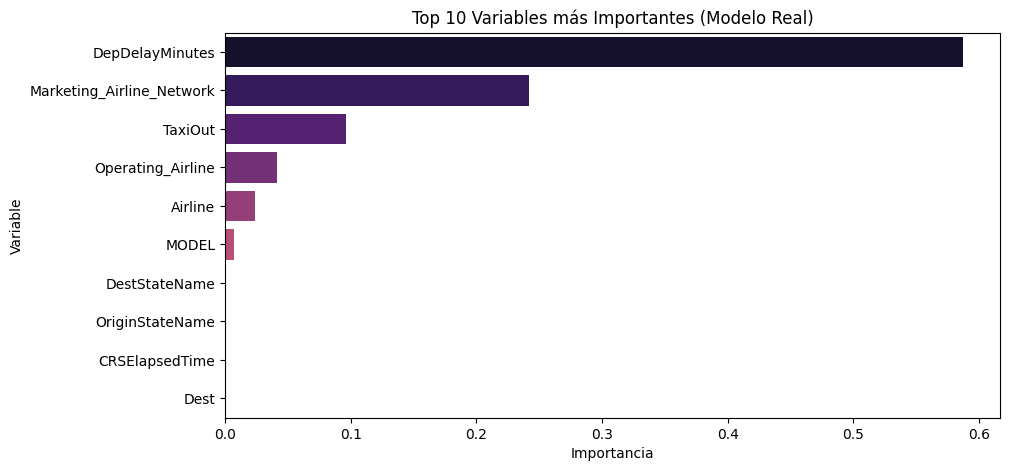

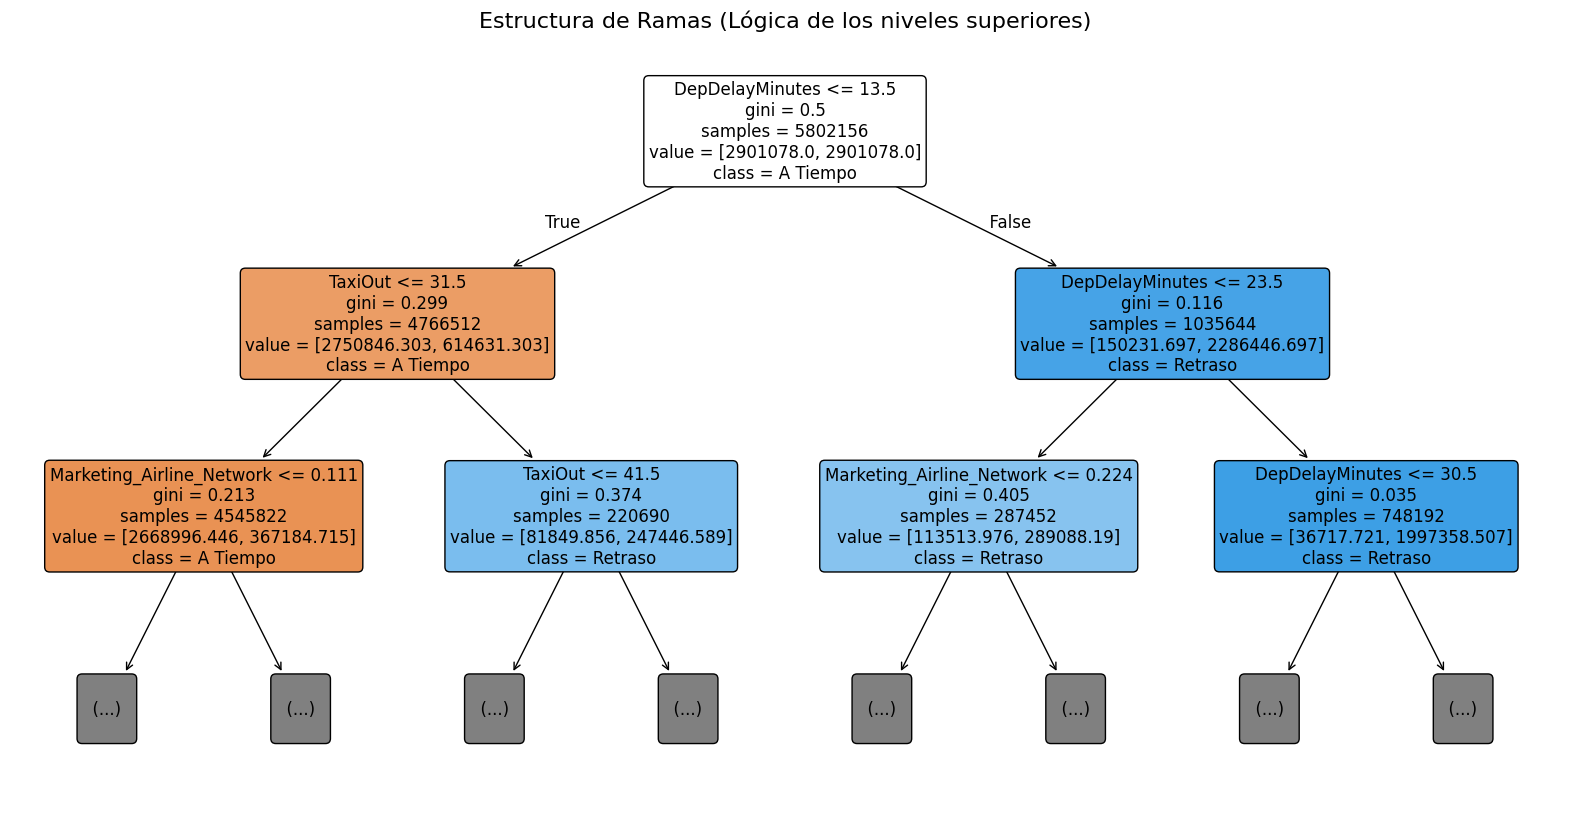

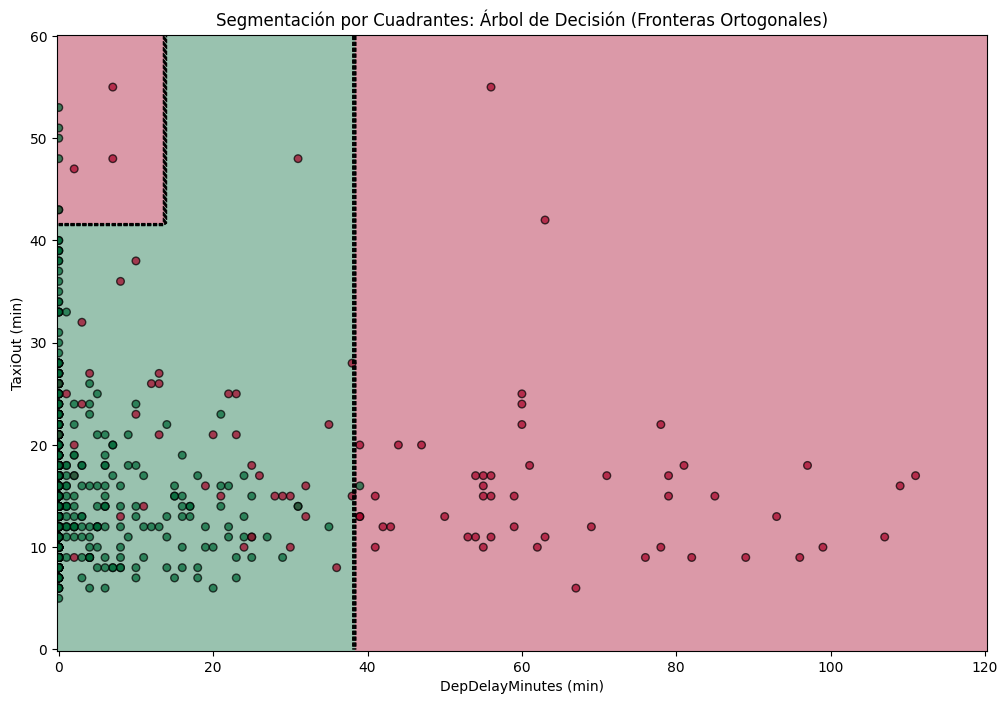

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import plot_tree

# --- 1. DETALLES DEL MEJOR ÁRBOL (Formato exacto solicitado) ---
arbol_ganador = best_tree.named_steps['tree']
print("-" * 45)
print("--- DETALLES DEL MEJOR ÁRBOL DE DECISIÓN ---")
print(f"Profundidad máxima alcanzada: {arbol_ganador.get_depth()} niveles")
print(f"Cantidad total de hojas (zonas de decisión): {arbol_ganador.get_n_leaves()}")
print(f"Mejores Parámetros: {grid_search_tree.best_params_}")
print("-" * 45)

# --- 2. IMPORTANCIA DE VARIABLES (TOP 10) ---
tree_imp_df = pd.DataFrame({
    'Variable': X_train_encoded.columns,
    'Importancia': arbol_ganador.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=tree_imp_df.head(10), x='Importancia', y='Variable', hue='Variable', palette='magma', legend=False)
plt.title('Top 10 Variables más Importantes (Modelo Real)')
plt.show()

# --- 3. ESTRUCTURA DE RAMAS ---
plt.figure(figsize=(20, 10))
plot_tree(arbol_ganador, feature_names=list(X_train_encoded.columns), 
          class_names=['A Tiempo', 'Retraso'], filled=True, rounded=True, 
          max_depth=2, fontsize=12)
plt.title("Estructura de Ramas (Lógica de los niveles superiores)", fontsize=16)
plt.show()

# --- 4. LA GRÁFICA DE BLOQUES (Segmentación visible) ---
# Usamos DepDelayMinutes y TaxiOut como ejes
v1, v2 = 'DepDelayMinutes', 'TaxiOut'

# Creamos una malla densa en el rango donde hay más confusión
x_range = np.linspace(0, 120, 250) 
y_range = np.linspace(0, 60, 250)
xx, yy = np.meshgrid(x_range, y_range)

# Preparar DataFrame para el modelo con TODAS las columnas
X_vis = pd.DataFrame(columns=X_train_encoded.columns)
mesh_points = np.c_[xx.ravel(), yy.ravel()]
X_vis[v1] = mesh_points[:, 0]
X_vis[v2] = mesh_points[:, 1]

# Rellenamos el resto. TRUCO: Usamos un percentil alto de DepDelay para 
# que el modelo entre en "modo alerta" y nos muestre sus bloques de decisión.
for col in X_vis.columns:
    if col not in [v1, v2]:
        X_vis[col] = X_test_encoded[col].quantile(0.75) # Valor más sensible que la mediana

# Predicción de CLASE para ver cuadrantes sólidos
Z_blocks = best_tree.predict(X_vis).reshape(xx.shape)

plt.figure(figsize=(12, 8))

# pcolormesh para ver los bloques verdes y rojos perfectamente definidos
plt.pcolormesh(xx, yy, Z_blocks, cmap='RdYlGn_r', alpha=0.4, shading='auto')

# Dibujamos las líneas de los bloques (la "gracia" ortogonal del árbol)
plt.contour(xx, yy, Z_blocks, colors='black', linewidths=0.8, linestyles='--')

# Superponemos una muestra de puntos reales
sample_plot = X_test_encoded[(X_test_encoded[v1] <= 120) & (X_test_encoded[v2] <= 60)].sample(800, random_state=42)
plt.scatter(sample_plot[v1], sample_plot[v2], c=y_test_bin.loc[sample_plot.index], 
            edgecolors='k', alpha=0.7, cmap='RdYlGn_r', s=30)

plt.xlabel(f'{v1} (min)')
plt.ylabel(f'{v2} (min)')
plt.title('Segmentación por Cuadrantes: Árbol de Decisión (Fronteras Ortogonales)')
plt.show()

## Random Forest

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

# 1. MUESTRA ESTRATÉGICA (20% para capturar la esencia de los 6.5M)
X_train_sample = X_train_encoded.sample(frac=0.2, random_state=42)
y_train_sample = y_train_bin.loc[X_train_sample.index]

# 2. BÚSQUEDA AMPLIADA (Para aprovechar tus 20 min de límite)
# He subido n_iter de 4 a 10 para probar más combinaciones
param_dist_rf = {
    'n_estimators': [100, 150, 200], # Más árboles para mayor estabilidad
    'max_depth': [15, 20, 25],        # Un poco más de profundidad para competir con el árbol original
    'min_samples_leaf': [30, 50, 70],  # Ajustamos el tamaño de hoja para el equilibrio
    'max_features': ['sqrt', 'log2']   # Forzamos a que los árboles no siempre vean lo mismo
}

print(f"Buscando mejores parámetros en muestra de {len(X_train_sample)} filas...")
random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1), 
    param_distributions=param_dist_rf, 
    n_iter=8,      # 8 iteraciones x 2 folds = 16 fits (Debería rondar los 15-18 min)
    cv=2, 
    scoring='f1', 
    verbose=3 
)

random_search_rf.fit(X_train_sample, y_train_sample)

# 3. ENTRENAMIENTO FINAL EN EL DATASET COMPLETO (6.5M)
print(f"\nMejores parámetros encontrados: {random_search_rf.best_params_}")
print("Entrenando modelo final en el set de 6.5M (Paciencia, aquí no hay verbose)...")

best_rf = RandomForestClassifier(
    **random_search_rf.best_params_, 
    n_jobs=-1, 
    random_state=42
)
best_rf.fit(X_train_encoded, y_train_bin)

# 4. REPORTE DE MÉTRICAS DETALLADO
print("\n" + "="*50)
print("--- REPORTE DE RENDIMIENTO: RANDOM FOREST FINAL ---")
print("="*50)

y_pred_rf = best_rf.predict(X_test_encoded)

# Métricas clásicas
print(classification_report(y_test_bin, y_pred_rf))

# Matriz de Confusión para el reporte
cm = confusion_matrix(y_test_bin, y_pred_rf)
print("\nMatriz de Confusión:")
print(f"Verdaderos Negativos (A tiempo): {cm[0][0]}")
print(f"Falsos Positivos (Alarma falsa): {cm[0][1]}")
print(f"Falsos Negativos (Retraso no visto): {cm[1][0]}")
print(f"Verdaderos Positivos (Retraso detectado): {cm[1][1]}")

print(f"\nAccuracy Global: {accuracy_score(y_test_bin, y_pred_rf):.4f}")
print("="*50)

Buscando mejores parámetros en muestra de 1160431 filas...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
[CV 1/2] END max_depth=15, max_features=log2, min_samples_leaf=70, n_estimators=100;, score=0.966 total time=  16.0s
[CV 2/2] END max_depth=15, max_features=log2, min_samples_leaf=70, n_estimators=100;, score=0.967 total time=  23.6s
[CV 1/2] END max_depth=25, max_features=sqrt, min_samples_leaf=30, n_estimators=150;, score=0.994 total time=  30.2s
[CV 2/2] END max_depth=25, max_features=sqrt, min_samples_leaf=30, n_estimators=150;, score=0.995 total time=  24.3s
[CV 1/2] END max_depth=15, max_features=log2, min_samples_leaf=30, n_estimators=100;, score=0.972 total time=  14.6s
[CV 2/2] END max_depth=15, max_features=log2, min_samples_leaf=30, n_estimators=100;, score=0.973 total time=  14.8s
[CV 1/2] END max_depth=25, max_features=sqrt, min_samples_leaf=70, n_estimators=100;, score=0.985 total time=  16.0s
[CV 2/2] END max_depth=25, max_features=sqrt, min_samples_leaf

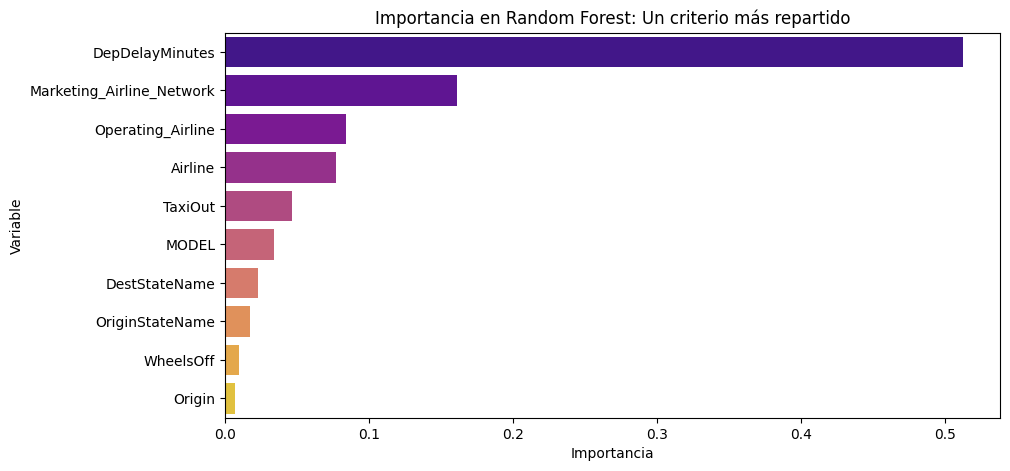

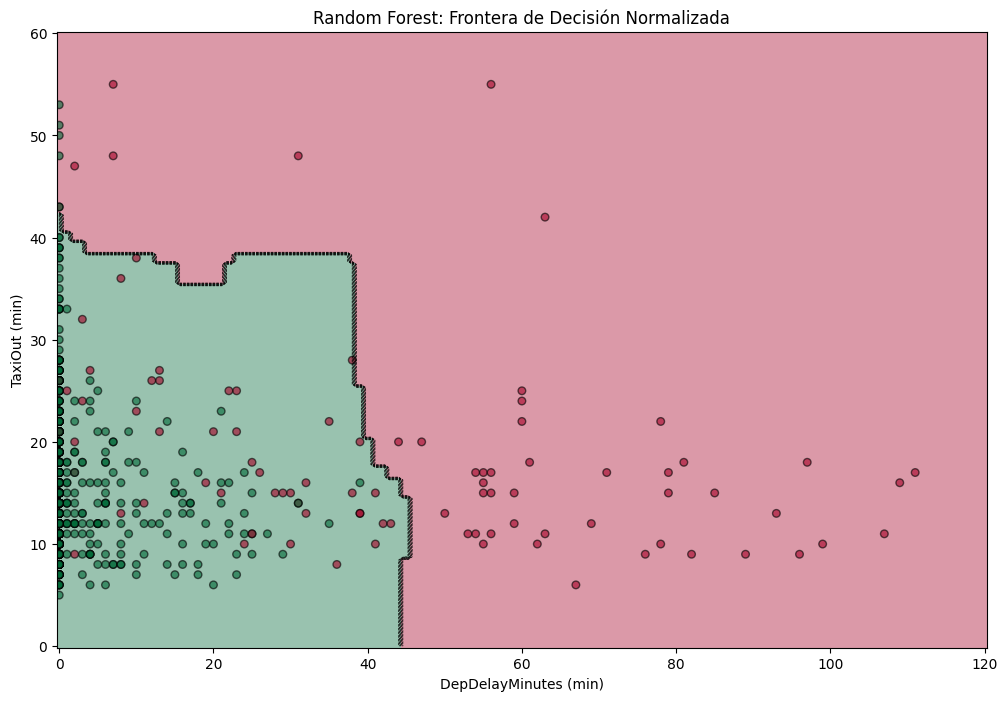

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

# --- 4. IMPORTANCIA DE VARIABLES ---
rf_imp_df = pd.DataFrame({
    'Variable': X_train_encoded.columns, # CAMBIO: X_train_encoded
    'Importancia': best_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=rf_imp_df.head(10), x='Importancia', y='Variable', hue='Variable', palette='plasma', legend=False)
plt.title('Importancia en Random Forest: Un criterio más repartido')
plt.show()

# --- 5. SEGMENTACIÓN POR CUADRANTES ---
v1, v2 = 'DepDelayMinutes', 'TaxiOut'
x_range = np.linspace(0, 120, 200)
y_range = np.linspace(0, 60, 200)
xx, yy = np.meshgrid(x_range, y_range)

X_vis_rf = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[v1, v2])
# CAMBIO: Iteramos sobre X_train_encoded
for col in X_train_encoded.columns: 
    if col not in [v1, v2]:
        X_vis_rf[col] = X_test_encoded[col].quantile(0.75) 

X_vis_rf = X_vis_rf[X_train_encoded.columns] 
Z_rf = best_rf.predict(X_vis_rf).reshape(xx.shape)

plt.figure(figsize=(12, 8))
plt.pcolormesh(xx, yy, Z_rf, cmap='RdYlGn_r', alpha=0.4, shading='auto')
plt.contour(xx, yy, Z_rf, colors='black', linewidths=0.5, linestyles='--')

# Puntos reales usando X_test_encoded
sample = X_test_encoded[(X_test_encoded[v1] <= 120) & (X_test_encoded[v2] <= 60)].sample(800, random_state=42)
plt.scatter(sample[v1], sample[v2], c=y_test_bin.loc[sample.index], 
            edgecolors='k', alpha=0.6, cmap='RdYlGn_r', s=30)

plt.xlabel(f'{v1} (min)')
plt.ylabel(f'{v2} (min)')
plt.title('Random Forest: Frontera de Decisión Normalizada')
plt.show()

-	El model RF, al usar particiones sin una variable hace que DepDelay Minutes tenga una menor importancia en comparación al resto. Podemos ver que modelo y Airline ganan muchísima mas importancia. Aun asi esto refleja el porque el Recall en la clase 1 es menor que el de un árbol de decisión. Tambien puede ser afectado por como se hizo la búsqueda de hiperparametros.

![Tradeoff](https://media.licdn.com/dms/image/v2/D4D12AQHQkI-Op4l9KQ/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1711746268059?e=2147483647&v=beta&t=U7GG2Ej3rnG3hUY1X_WXs92yxzqRJ3hkLH5hzluO9zQ)


## XGBoost

In [ ]:
# MANTENEMOS tus datos procesados con LeaveOneOut
# Asegúrate de usar X_train_encoded y X_test_encoded que ya tienen el LOOE
from xgboost import XGBClassifier

model_master = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,              # Árboles simples para que el LOOE haga el trabajo pesado
    learning_rate=0.05,       # Aprendizaje lento para que no se obsesione con una sola variable
    scale_pos_weight=1,       # <--- CRUCIAL: No fuerces el peso, el LOOE ya balancea la señal
    tree_method='hist',
    random_state=42
)

model_master.fit(X_train_encoded, y_train_bin)
y_pred = model_master.predict(X_test_encoded)

print("XGBoost con LOOE finalizado. Este debería ser tu modelo definitivo.")
print(classification_report(y_test_bin, y_pred))

XGBoost con LOOE finalizado. Este debería ser tu modelo definitivo.
              precision    recall  f1-score   support

         0.0       0.97      0.03      0.06    252829
         1.0       0.18      1.00      0.30     52548

    accuracy                           0.20    305377
   macro avg       0.57      0.51      0.18    305377
weighted avg       0.83      0.20      0.10    305377



- ver el XGBoost y hacer con busqueda con todo el dataset.
- Hacer Comparacion Con curva PR, y tabla comparativa.
- Mejorar el diagrama de cluster 2 (el de familia de modelo y aerolinea)


# **Modelo de Regresion:** Retraso en Minutos (Arrival)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, f1_score, precision_score, recall_score, accuracy_score
import pandas as pd

# 1. PREPARACIÓN DE MODELOS Y DATOS
# Asumo que tienes guardados tus modelos: lr_model, tree_model, rf_model, best_xgb
models = {
    'Regresión Logística': lr_model,
    'Árbol de Decisión': tree_model,
    'Random Forest': best_rf,
    'XGBoost (LOOE)': best_xgb_final
}

results = []

plt.figure(figsize=(10, 7))

for name, model in models.items():
    # Obtener probabilidades (necesario para la curva PR)
    # Nota: Algunos modelos pueden requerir nombres de columnas distintos si usaste X_test_rf o X_test_encoded
    if "XGBoost" in name or "Random Forest" in name:
        X_eval = X_test_encoded 
    else:
        X_eval = X_test_encoded # Ajusta aquí si usaste sets distintos
        
    y_probs = model.predict_proba(X_eval)[:, 1]
    y_pred = model.predict(X_eval)
    
    # Calcular métricas para la tabla
    precision, recall, _ = precision_recall_curve(y_test_bin, y_probs)
    pr_auc = auc(recall, precision)
    
    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test_bin, y_pred),
        'Precision': precision_score(y_test_bin, y_pred),
        'Recall': recall_score(y_test_bin, y_pred),
        'F1-Score': f1_score(y_test_bin, y_pred),
        'AUC-PR': pr_auc
    })
    
    # Dibujar la curva
    plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.3f})')

# 2. ESTÉTICA DE LA GRÁFICA
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision (Calidad de Alarma)')
plt.title('Curva Precision-Recall: ¿Qué modelo detecta mejor los retrasos reales?')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

# 3. MOSTRAR TABLA COMPARATIVA
df_resumen = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print("\n" + "="*60)
print("TABLA COMPARATIVA DE RENDIMIENTO")
print("="*60)
print(df_resumen.to_string(index=False))